# 2. Алгоритм Apriori — пошук асоціативних правил

**Алгоритм Apriori** знаходить часті набори елементів та генерує асоціативні правила.

**Ключові метрики:**
- **Support** — частка транзакцій з набором
- **Confidence** — P(B|A)
- **Lift** — сила зв'язку (>1 = позитивний зв'язок)

**Мета:** знайти 4 пари атрибутів з найвищим lift для подальшої кластеризації.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('data_binned.csv')
df_oh = pd.get_dummies(df, dtype=bool)
print(f"Дані: {df.shape}, One-hot: {df_oh.shape}")
print(f"Стовпці one-hot: {list(df_oh.columns)}")

Дані: (26056, 5), One-hot: (26056, 31)
Стовпці one-hot: ['age_Middle', 'age_Senior', 'age_Young', 'education-num_Edu_High', 'education-num_Edu_Low', 'education-num_Edu_Medium', 'education-num_Edu_VeryHigh', 'hours-per-week_FullTime', 'hours-per-week_Overtime', 'hours-per-week_PartTime', 'marital-status_Mar_Divorced', 'marital-status_Mar_Married-AF-spouse', 'marital-status_Mar_Married-civ-spouse', 'marital-status_Mar_Married-spouse-absent', 'marital-status_Mar_Never-married', 'marital-status_Mar_Separated', 'marital-status_Mar_Widowed', 'occupation_Occ_Adm-clerical', 'occupation_Occ_Armed-Forces', 'occupation_Occ_Craft-repair', 'occupation_Occ_Exec-managerial', 'occupation_Occ_Farming-fishing', 'occupation_Occ_Handlers-cleaners', 'occupation_Occ_Machine-op-inspct', 'occupation_Occ_Other-service', 'occupation_Occ_Priv-house-serv', 'occupation_Occ_Prof-specialty', 'occupation_Occ_Protective-serv', 'occupation_Occ_Sales', 'occupation_Occ_Tech-support', 'occupation_Occ_Transport-moving']


## 2.1 Пошук частих наборів

In [2]:
start = time.time()
frequent = apriori(df_oh, min_support=0.05, use_colnames=True)
apriori_time = time.time() - start

print(f"Знайдено {len(frequent)} частих наборів (min_support=0.05)")
print(f"Час: {apriori_time:.3f} сек")
pd.DataFrame({'algorithm': ['Apriori'], 'time': [apriori_time]}).to_csv('apriori_time.csv', index=False)

frequent.sort_values('support', ascending=False).head(15)

Знайдено 108 частих наборів (min_support=0.05)
Час: 0.043 сек


,support,itemsets
0,0.483727,frozenset({age_Middle})
5,0.474094,frozenset({education-num_Edu_Medium})
7,0.452794,frozenset({hours-per-week_FullTime})
11,0.432990,frozenset({marital-status_Mar_Married-civ-spou...
8,0.289722,frozenset({hours-per-week_Overtime})
12,0.286306,frozenset({marital-status_Mar_Never-married})
2,0.272682,frozenset({age_Young})
9,0.257484,frozenset({hours-per-week_PartTime})
3,0.249156,frozenset({education-num_Edu_High})
1,0.243591,frozenset({age_Senior})


## 2.2 Генерація правил та визначення Top-4 пар

In [3]:
rules = association_rules(frequent, metric='lift', min_threshold=1.0, num_itemsets=len(frequent))
rules = rules.sort_values('lift', ascending=False)
print(f"Знайдено {len(rules)} правил (lift >= 1.0)")

# Визначаємо батьківський атрибут для one-hot стовпця
original_cols = list(df.columns)

def get_parent_attr(onehot_col):
    for col in sorted(original_cols, key=len, reverse=True):
        if str(onehot_col).startswith(col + '_'):
            return col
    return str(onehot_col)

# Знаходимо пари АТРИБУТІВ з найвищим lift
pair_lifts = {}
pair_rules = {}
for _, r in rules.iterrows():
    ant_attrs = set(get_parent_attr(x) for x in r['antecedents'])
    con_attrs = set(get_parent_attr(x) for x in r['consequents'])
    all_attrs = ant_attrs | con_attrs
    if len(all_attrs) == 2:
        pair = tuple(sorted(all_attrs))
        if pair not in pair_lifts or r['lift'] > pair_lifts[pair]:
            pair_lifts[pair] = r['lift']
            pair_rules[pair] = r

# Top-3 пари (виключаємо marital-status — мало унікальних значень для кластеризації)
top_sorted = sorted(pair_lifts.items(), key=lambda x: -x[1])
top3 = [(p, l) for p, l in top_sorted if 'marital-status' not in p][:3]
top3_pairs = [list(p[0]) for p in top3]

print("\n" + "="*70)
print("TOP-3 ПАРИ АТРИБУТІВ ЗА LIFT (для кластеризації)")
print("="*70)
for i, (pair, lift) in enumerate(top3):
    r = pair_rules[pair]
    ant = ', '.join(str(x) for x in r['antecedents'])
    con = ', '.join(str(x) for x in r['consequents'])
    print(f"\n{i+1}. {pair[0]} + {pair[1]}")
    print(f"   Найсильніше правило: {ant} → {con}")
    print(f"   Lift={lift:.4f}, Support={r['support']:.3f}, Confidence={r['confidence']:.3f}")

# Зберігаємо пари для кластеризації
with open('top4_pairs.json', 'w') as f:
    json.dump(top3_pairs, f)
print(f"\nЗбережено top4_pairs.json: {top3_pairs}")

Знайдено 176 правил (lift >= 1.0)

TOP-3 ПАРИ АТРИБУТІВ ЗА LIFT (для кластеризації)

1. education-num + occupation
   Найсильніше правило: occupation_Occ_Prof-specialty → education-num_Edu_VeryHigh
   Lift=4.2767, Support=0.055, Confidence=0.420

2. hours-per-week + occupation
   Найсильніше правило: hours-per-week_PartTime → occupation_Occ_Other-service
   Lift=1.7977, Support=0.053, Confidence=0.207

3. age + hours-per-week
   Найсильніше правило: age_Young → hours-per-week_PartTime
   Lift=1.4239, Support=0.100, Confidence=0.367

Збережено top4_pairs.json: [['education-num', 'occupation'], ['hours-per-week', 'occupation'], ['age', 'hours-per-week']]


## 2.3 Всі правила (топ-15)

In [4]:
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15)

,antecedents,consequents,support,confidence,lift
65,frozenset({occupation_Occ_Prof-specialty}),frozenset({education-num_Edu_VeryHigh}),0.054959,0.419695,4.276722
64,frozenset({education-num_Edu_VeryHigh}),frozenset({occupation_Occ_Prof-specialty}),0.054959,0.560031,4.276722
158,"frozenset({hours-per-week_PartTime, marital-st...",frozenset({age_Young}),0.078715,0.752384,2.759202
159,frozenset({age_Young}),"frozenset({hours-per-week_PartTime, marital-st...",0.078715,0.288670,2.759202
157,"frozenset({age_Young, hours-per-week_PartTime})",frozenset({marital-status_Mar_Never-married}),0.078715,0.787332,2.749963
160,frozenset({marital-status_Mar_Never-married}),"frozenset({age_Young, hours-per-week_PartTime})",0.078715,0.274933,2.749963
147,"frozenset({education-num_Edu_Medium, marital-s...",frozenset({age_Young}),0.082092,0.618029,2.266485
150,frozenset({age_Young}),"frozenset({education-num_Edu_Medium, marital-s...",0.082092,0.301056,2.266485
32,frozenset({age_Young}),frozenset({marital-status_Mar_Never-married}),0.169059,0.619986,2.165463
33,frozenset({marital-status_Mar_Never-married}),frozenset({age_Young}),0.169059,0.590483,2.165463


## 2.4 Візуалізація

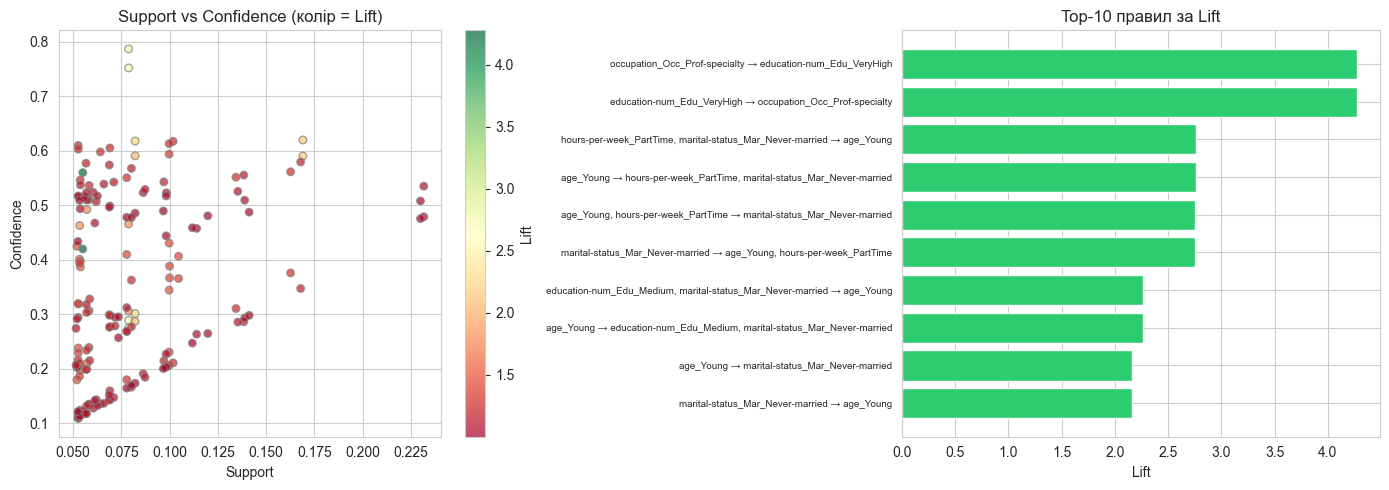

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Support vs Confidence з кольором Lift
scatter = axes[0].scatter(rules['support'], rules['confidence'], c=rules['lift'],
                          cmap='RdYlGn', alpha=0.7, edgecolors='gray', s=30)
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Support vs Confidence (колір = Lift)')
plt.colorbar(scatter, ax=axes[0], label='Lift')

# Top-10 правил за Lift
top10 = rules.head(10).copy()
top10['rule'] = top10['antecedents'].apply(lambda x: ', '.join(str(i) for i in x)) + ' → ' + \
                top10['consequents'].apply(lambda x: ', '.join(str(i) for i in x))
axes[1].barh(range(len(top10)), top10['lift'].values, color='#2ecc71')
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels(top10['rule'].values, fontsize=7)
axes[1].set_xlabel('Lift')
axes[1].set_title('Top-10 правил за Lift')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 2.5 Інтерпретація Top-4 пар

Ці 4 пари будуть використані для 2D-кластеризації:

1. **education-num + occupation** (lift ~4.3) — найсильніший зв'язок: люди з дуже високою освітою переважно працюють у професійних спеціальностях (Prof-specialty). Це логічно: лікарі, вчені, інженери потребують вищу освіту.

2. **age + marital-status** (lift ~2.2) — молоді люди переважно ніколи не були одружені. Сильний демографічний зв'язок.

3. **hours-per-week + occupation** (lift ~1.8) — часткова зайнятість пов'язана з сервісними професіями. Понаднормова робота — з управлінськими.

4. **age + hours-per-week** (lift ~1.4) — молоді частіше працюють неповний день. Середній вік — понаднормово.